In [15]:
!pip install -q opendatasets seaborn

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/ebisagetachew/dragamen")

Skipping, found downloaded files in "./dragamen" (use force=True to force download)


In [17]:
dataset_dir = "dragamen/emotion_dataset"

train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: dragamen/emotion_dataset/train
Test path: dragamen/emotion_dataset/test


In [18]:
IMAGE_SIZE = (48, 48)
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 7

COLOR_MODE = "grayscale"   # IMPORTANT FIX

In [20]:
import os

print(os.listdir("dragamen"))

['train', 'test']


In [21]:
train_dir = "dragamen/train"
test_dir  = "dragamen/test"

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode=COLOR_MODE,
    subset='training',
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode=COLOR_MODE,
    subset='validation',
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode=COLOR_MODE,
    shuffle=False
)

Found 35840 images belonging to 7 classes.
Found 8960 images belonging to 7 classes.
Found 11200 images belonging to 7 classes.


In [23]:
print("Class indices:", train_gen.class_indices)

Class indices: {'anger': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [24]:
inputs = Input(shape=(48,48,1))  # grayscale

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,639 (3.74 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
os.makedirs("models", exist_ok=True)

model_path = "models/emotion_cnn.keras"

callbacks = [
    ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

In [26]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1689 - loss: 2.0851
Epoch 1: val_loss improved from None to 1.93203, saving model to models/emotion_cnn.keras

Epoch 1: finished saving model to models/emotion_cnn.keras
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 71s 55ms/step - accuracy: 0.1838 - loss: 1.9549 - val_accuracy: 0.1772 - val_loss: 1.9320 - learning_rate: 0.0010
Epoch 2/25
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2131 - loss: 1.8859
Epoch 2: val_loss improved from 1.93203 to 1.78532, saving model to models/emotion_cnn.keras

Epoch 2: finished saving model to models/emotion_cnn.keras
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 50s 45ms/step - accuracy: 0.2221 - loss: 1.8687 - val_accuracy: 0.3071 - val_loss: 1.7853 - learning_rate: 0.0010
Epoch 3/25
1119/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2630 - loss: 1.8016
Epoch 3: val_loss improved from 1.78532 to 1.71148, saving model to models/emotion_cnn.keras

Epoch 3: finished saving model to models/emoti

In [27]:
model = keras.models.load_model(model_path)

loss, acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc*100:.2f}%")

Test Loss: 1.0396
Test Accuracy: 61.04%


In [28]:
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1-score: {f1:.4f}")

class_names = list(train_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step
F1-score: 0.6018

Classification Report:
              precision    recall  f1-score   support

       anger       0.56      0.47      0.51      1600
     disgust       0.72      0.81      0.76      1600
        fear       0.48      0.28      0.36      1600
       happy       0.85      0.77      0.81      1600
     neutral       0.48      0.71      0.57      1600
         sad       0.48      0.46      0.47      1600
    surprise       0.70      0.78      0.74      1600

    accuracy                           0.61     11200
   macro avg       0.61      0.61      0.60     11200
weighted avg       0.61      0.61      0.60     11200



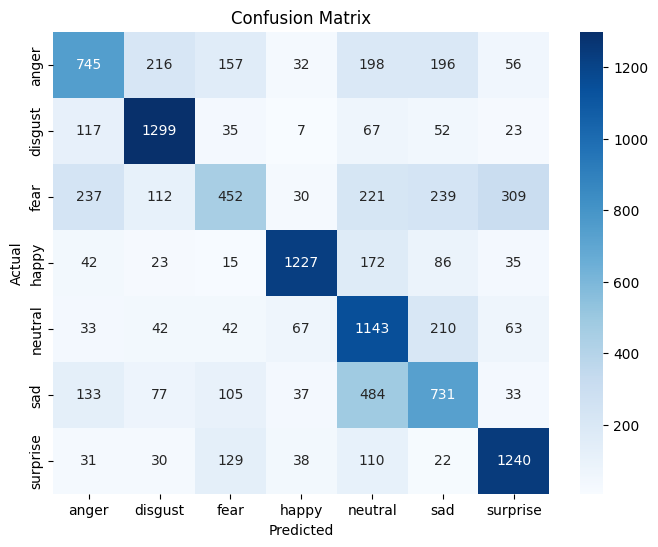

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()